# 04_VisualizeMajor_vs_NonMajor

`03_BreathDetect.py` 산출물에서 유저(환자)별 Edi 신호와 Major/Non-major cluster 구간을 시각화합니다.

- Major Cluster: 옅은 녹색
- Non Major Cluster: 옅은 빨강

In [5]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (15, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

OUTPUT_ROOT = (Path.cwd() / 'outputs' / '03_breath_detect').resolve()

def list_analysis_folders(root: Path):
    if not root.exists():
        return []
    return sorted([p.name for p in root.iterdir() if p.is_dir()])

def list_patient_ids(analysis_folder: str):
    folder = OUTPUT_ROOT / analysis_folder
    if not folder.exists():
        return []

    ids = []
    for p in sorted(folder.glob('patient_*')):
        m = re.match(r'patient_(.+)$', p.name)
        if not m:
            continue
        pid = m.group(1)
        edi_fp = p / f'patient_{pid}_edi_filtered_signal.csv'
        clu_fp = p / f'patient_{pid}_clustered_breaths.csv'
        if edi_fp.exists() and clu_fp.exists():
            ids.append(pid)
    return ids

def patient_paths(analysis_folder: str, patient_id: str):
    base = OUTPUT_ROOT / analysis_folder / f'patient_{patient_id}'
    return {
        'base': base,
        'edi': base / f'patient_{patient_id}_edi_filtered_signal.csv',
        'cluster': base / f'patient_{patient_id}_clustered_breaths.csv'
    }

def build_segment_df(cluster_df: pd.DataFrame):
    keep = ['breath_id', 'v_start_idx', 'v_end_idx', 'cluster_label', 'major_cluster']
    seg = cluster_df[keep].copy()
    seg['v_start_idx'] = pd.to_numeric(seg['v_start_idx'], errors='coerce').astype('Int64')
    seg['v_end_idx'] = pd.to_numeric(seg['v_end_idx'], errors='coerce').astype('Int64')
    seg = seg.dropna(subset=['v_start_idx', 'v_end_idx']).copy()
    seg['v_start_idx'] = seg['v_start_idx'].astype(int)
    seg['v_end_idx'] = seg['v_end_idx'].astype(int)
    seg['major_cluster'] = seg['major_cluster'].astype(str).str.lower().isin(['1', 'true', 't', 'yes'])
    seg = seg.sort_values(['v_start_idx', 'v_end_idx']).reset_index(drop=True)
    return seg

In [6]:
# 1) 제일 상단: 분석 폴더/유저 선택
analysis_options = list_analysis_folders(OUTPUT_ROOT)
print('Available analysis folders:', analysis_options)

ANALYSIS_FOLDER = '20260301'   # 여기 수정
patient_options = list_patient_ids(ANALYSIS_FOLDER)
print(f'Available patients in {ANALYSIS_FOLDER}:', patient_options)

PATIENT_ID = '05'
print('Selected patient:', PATIENT_ID)

Available analysis folders: ['20260301']
Available patients in 20260301: ['03', '04', '05', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']
Selected patient: 05


In [7]:
# 2) 선택한 유저 데이터 로드
if PATIENT_ID is None:
    raise ValueError('선택 가능한 patient가 없습니다. ANALYSIS_FOLDER를 확인하세요.')

paths = patient_paths(ANALYSIS_FOLDER, PATIENT_ID)
edi_df = pd.read_csv(paths['edi'])
cluster_df = pd.read_csv(paths['cluster'])
seg_df = build_segment_df(cluster_df)

if 'sample_idx' not in edi_df.columns:
    edi_df = edi_df.reset_index().rename(columns={'index': 'sample_idx'})

print(f'Loaded: analysis={ANALYSIS_FOLDER}, patient={PATIENT_ID}')
print(f'EDI rows: {len(edi_df):,}')
print(f'Breath segments: {len(seg_df):,}')

Loaded: analysis=20260301, patient=05
EDI rows: 400,000
Breath segments: 1,389


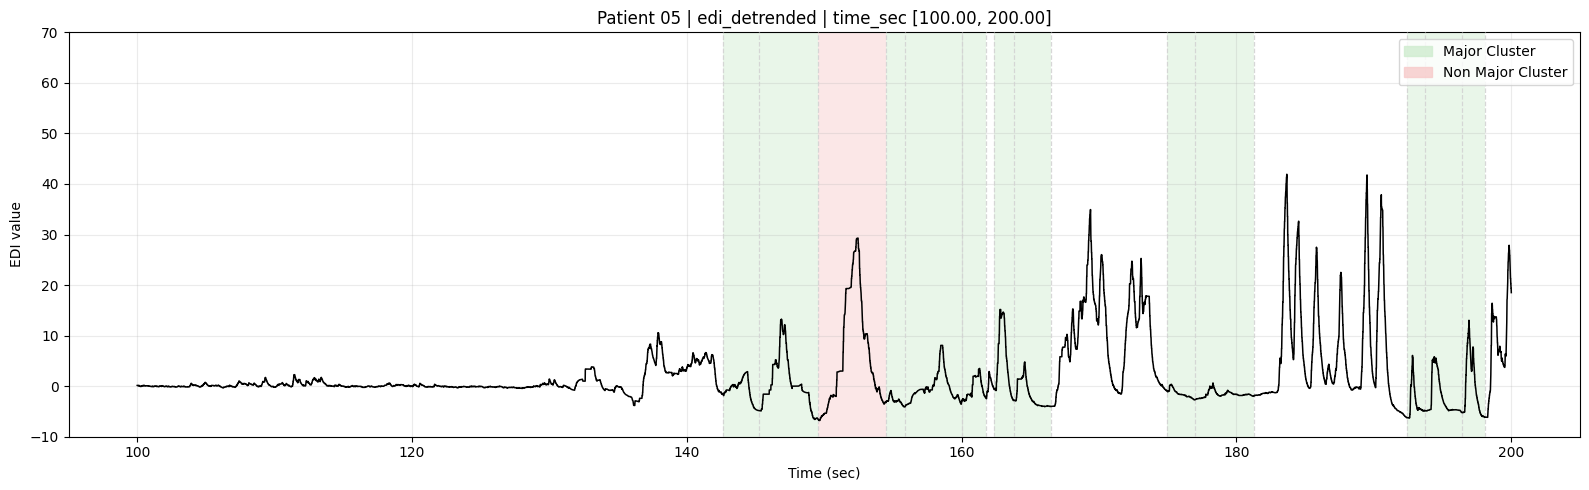

겹치는 breath segment: total=13, major=12, non-major=1


In [8]:
# 3) 원하는 구간 직접 선택해서 시각화 (x축: 초 단위, 100Hz)
SIGNAL_COL = 'edi_detrended'   # ['edi_detrended', 'edi_smooth_for_detection', 'edi_raw']
FS_HZ = 100.0
START_SEC = 100.0
END_SEC = START_SEC + 100.0

MAJOR_COLOR = '#cfeccf'      # 옅은 녹색
NON_MAJOR_COLOR = '#f7caca'  # 옅은 빨강

def plot_segment(
    edi_df: pd.DataFrame,
    seg_df: pd.DataFrame,
    signal_col: str,
    start_sec: float,
    end_sec: float,
    patient_id: str,
    fs_hz: float = 100.0,
):
    if signal_col not in edi_df.columns:
        raise KeyError(f'컬럼이 없습니다: {signal_col}')
    if fs_hz <= 0:
        raise ValueError('fs_hz must be > 0')

    s_sec = float(min(start_sec, end_sec))
    e_sec = float(max(start_sec, end_sec))

    s = max(int(round(s_sec * fs_hz)), int(edi_df['sample_idx'].min()))
    e = min(int(round(e_sec * fs_hz)), int(edi_df['sample_idx'].max()))

    sub = edi_df[(edi_df['sample_idx'] >= s) & (edi_df['sample_idx'] <= e)].copy()
    if sub.empty:
        print('선택 구간에 데이터가 없습니다.')
        return

    overlap = seg_df[(seg_df['v_end_idx'] >= s) & (seg_df['v_start_idx'] <= e)].copy()

    fig, ax = plt.subplots(figsize=(16, 5))

    for _, r in overlap.iterrows():
        x0_idx = max(int(r['v_start_idx']), s)
        x1_idx = min(int(r['v_end_idx']), e)
        x0 = x0_idx / fs_hz
        x1 = x1_idx / fs_hz
        color = MAJOR_COLOR if bool(r['major_cluster']) else NON_MAJOR_COLOR
        ax.axvspan(x0, x1, color=color, alpha=0.45, lw=0)

    # Breath boundary (start/end) markers
    boundary_x = sorted(set(overlap['v_start_idx'].astype(int).tolist() + overlap['v_end_idx'].astype(int).tolist()))
    for bx in boundary_x:
        if s <= bx <= e:
            ax.axvline(bx / fs_hz, color='lightgray', linestyle='--', linewidth=0.9, alpha=0.9, zorder=3)

    x_sec = sub['sample_idx'] / fs_hz
    ax.plot(x_sec, sub[signal_col], color='black', linewidth=1.1, label=signal_col, zorder=4)

    major_patch = mpatches.Patch(color=MAJOR_COLOR, alpha=0.8, label='Major Cluster')
    non_patch = mpatches.Patch(color=NON_MAJOR_COLOR, alpha=0.8, label='Non Major Cluster')
    ax.legend(handles=[major_patch, non_patch], loc='upper right')
    # set y axis limits with some margin
    y_min = -10 
    y_max = 70
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'Patient {patient_id} | {signal_col} | time_sec [{s / fs_hz:.2f}, {e / fs_hz:.2f}]')
    ax.set_xlabel('Time (sec)')
    ax.set_ylabel('EDI value')
    plt.tight_layout()
    plt.show()

    if not overlap.empty:
        n_major = int(overlap['major_cluster'].sum())
        n_non = int((~overlap['major_cluster']).sum())
        print(f'겹치는 breath segment: total={len(overlap)}, major={n_major}, non-major={n_non}')
    else:
        print('선택 구간과 겹치는 breath segment가 없습니다.')

plot_segment(
    edi_df=edi_df,
    seg_df=seg_df,
    signal_col=SIGNAL_COL,
    start_sec=START_SEC,
    end_sec=END_SEC,
    patient_id=PATIENT_ID,
    fs_hz=FS_HZ,
)


### 사용 방법
1. 셀 `1) 제일 상단: 분석 폴더/유저 선택`에서 `ANALYSIS_FOLDER`, `PATIENT_ID` 수정
2. 셀 `2) 선택한 유저 데이터 로드` 실행
3. 셀 `3) 원하는 구간 직접 선택해서 시각화`에서 `START_SEC`, `END_SEC`, `SIGNAL_COL` 수정 후 실행